In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from sklearn.metrics import ( confusion_matrix,
    classification_report,
    roc_curve,auc)
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Keras version      : {keras.__version__}")
print()
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus}")
else:
    print("No GPU detected — using CPU")
tf.random.set_seed(42)
np.random.seed(42)
print()
print("Random seed set to 42 — results will be reproducible")

   TensorFlow version : 2.21.0
   Keras version      : 3.14.0

No GPU detected — using CPU

Random seed set to 42 — results will be reproducible


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────
PROCESSED_ROOT = Path("../data/processed")
TRAIN_DIR      = PROCESSED_ROOT / "training"
VAL_DIR        = PROCESSED_ROOT / "validation"
TEST_DIR       = PROCESSED_ROOT / "testing"
MODELS_DIR     = Path("../models")
RESULTS_DIR    = Path("../results")

# Create directories 
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────
IMG_SIZE      = (128, 128)   
IMG_SHAPE     = (128, 128, 3) 
BATCH_SIZE    = 32            # Files processed together in one training step
EPOCHS        = 30            # Maximum training rounds
LEARNING_RATE = 0.001         # How fast the model adjusts its weights
DROPOUT_RATE  = 0.3           # Fraction of neurons randomly disabled each step

# Model save path
MODEL_SAVE_PATH = MODELS_DIR / "vocal_armor_best.keras"

# ── Verify processed data exists ──────────────────────────────────────────
print("Checking processed spectrogram folders...")
print()

all_good = True
for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        folder = PROCESSED_ROOT / split / label
        count  = len(list(folder.glob("*.png"))) if folder.exists() else 0
        status = "✅" if count > 0 else "❌"
        print(f"  {status}  processed/{split}/{label:<12} → {count:>7,} images")
        if count == 0:
            all_good = False

print()
if all_good:
    print("All folders found! Ready to train.")
else:
    print("Some folders are empty. Make sure Cell 12 in notebook 01 completed fully.")

print()
print("Hyperparameters:")
print(f"Image size     : {IMG_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Max epochs     : {EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Dropout rate   : {DROPOUT_RATE}")

Checking processed spectrogram folders...

  ✅  processed/training/real         →   6,978 images
  ✅  processed/training/fake         →   6,978 images
  ✅  processed/validation/real         →   1,413 images
  ✅  processed/validation/fake         →   1,413 images
  ✅  processed/testing/real         →     544 images
  ✅  processed/testing/fake         →     544 images

All folders found! Ready to train.

Hyperparameters:
Image size     : (128, 128)
Batch size     : 32
Max epochs     : 30
Learning rate  : 0.001
Dropout rate   : 0.3


In [5]:
# Training generator WITH augmentation 
train_data_gen = ImageDataGenerator(
    rescale = 1./255,        # Normalize pixels from [0,255] to [0,1]
    horizontal_flip = True,  # Randomly mirror spectrogram
    zoom_range = 0.1,        # Random zoom up to 10%
    width_shift_range = 0.1,    # Random horizontal shift up to 10%
)
#Validation and Test generators WITHOUT augmentation 

eval_data_gen = ImageDataGenerator(rescale=1./255)
#Create the actual data loaders 
train_generator = train_data_gen.flow_from_directory(
    directory = TRAIN_DIR,  
    target_size = IMG_SIZE,          
    batch_size = BATCH_SIZE,        # loads 32 images
    class_mode = 'binary',      # binary classifiation
    shuffle = True,
    seed = 42
)
val_generator = eval_data_gen.flow_from_directory(
    directory  = VAL_DIR,
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle    = False,           # Never shuffle validation
    seed       = 42    
)
test_generator = eval_data_gen.flow_from_directory(
    directory  = TEST_DIR,
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle    = False,           # Never shuffle test set
    seed       = 42
)
print("Data Loader Summary")
print(f"Class mapping       : {train_generator.class_indices}")
print(f"Training samples    : {train_generator.samples:,}")
print(f"Validation samples  : {val_generator.samples:,}")
print(f"Test samples        : {test_generator.samples:,}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Training steps/epoch: {train_generator.samples // BATCH_SIZE}")
print()
print("Class mapping explanation:")
print("0 = fake  (the folder named 'fake')")
print("1 = real  (the folder named 'real')")
print("Model output > 0.5 = REAL, ≤ 0.5 = FAKE")

Found 13956 images belonging to 2 classes.
Found 2826 images belonging to 2 classes.
Found 1088 images belonging to 2 classes.
Data Loader Summary
Class mapping       : {'fake': 0, 'real': 1}
Training samples    : 13,956
Validation samples  : 2,826
Test samples        : 1,088
Batch size          : 32
Training steps/epoch: 436

Class mapping explanation:
0 = fake  (the folder named 'fake')
1 = real  (the folder named 'real')
Model output > 0.5 = REAL, ≤ 0.5 = FAKE


Batch shape: (32, 128, 128, 3)
means: 32 images, each 128×128 pixels, 3 color channels
Pixel value range: min=0.000, max=1.000
labels in this batch: [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1]
(0 = fake, 1 = real)


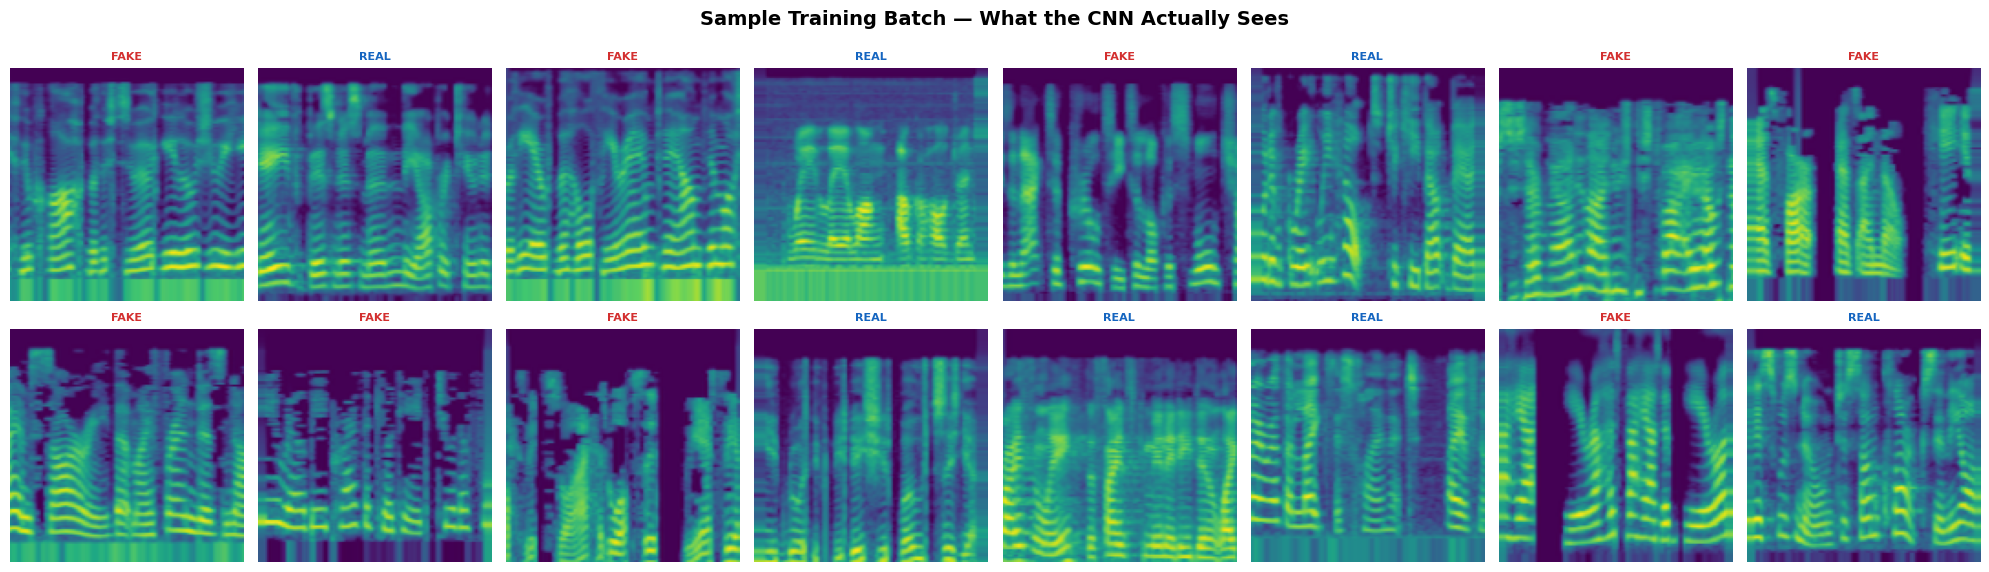

Saved to: ../results/06_training_batch_sample.png

If you can see spectrogram patterns — your data pipeline is working correctly!


In [8]:
sample_images, sample_labels = next(train_generator)
print(f"Batch shape: {sample_images.shape}")
print(f"means: {sample_images.shape[0]} images, each {sample_images.shape[1]}×{sample_images.shape[2]} pixels, {sample_images.shape[3]} color channels")
print(f"Pixel value range: min={sample_images.min():.3f}, max={sample_images.max():.3f}")
print(f"labels in this batch: {sample_labels[:16].astype(int).tolist()}")
print(f"(0 = fake, 1 = real)")
# ── Plot first 16 images
label_names = {v: k for k, v in train_generator.class_indices.items()}
colors      = {"fake": "#D32F2F", "real": "#1565C0"}

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Sample Training Batch — What the CNN Actually Sees",
             fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        ax.imshow(sample_images[i])
        label_name = label_names[int(sample_labels[i])]
        ax.set_title(label_name.upper(), fontsize=8,
                     color=colors[label_name], fontweight="bold")
    ax.axis("off")

plt.tight_layout()
save_path = RESULTS_DIR / "06_training_batch_sample.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")
print()
print("If you can see spectrogram patterns — your data pipeline is working correctly!")